In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv("../data/processed/dataset_1993_final_clean.csv")

print(df.shape)
df.head()

(2523, 3)


,id,text,label
0,EL189_L_1993_03_001_01_1_PF_01,elections legislatives de mars 93 front nation...,right
1,EL189_L_1993_03_001_01_1_PF_02,sciences po / fonds cevipof république françai...,left
2,EL189_L_1993_03_001_01_1_PF_03,sciences po / fonds cevipof elections législat...,right
3,EL189_L_1993_03_001_01_1_PF_04,elections législatives du 21 mars 1993 pourquo...,left
4,EL189_L_1993_03_001_01_1_PF_06,sciences po / fonds cevipof elections legislat...,left


## Exploration

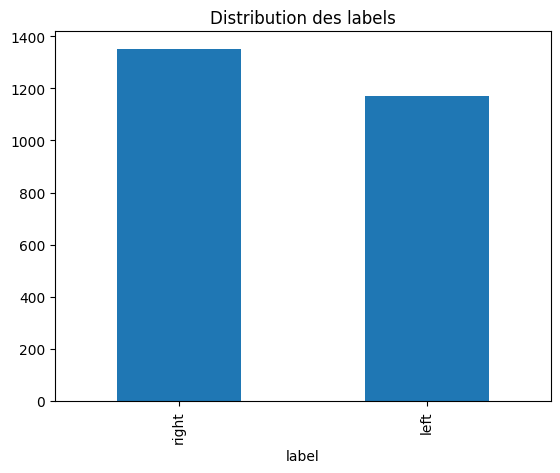

In [4]:
df['label'].value_counts().plot(kind='bar')
plt.title("Distribution des labels")
plt.show()

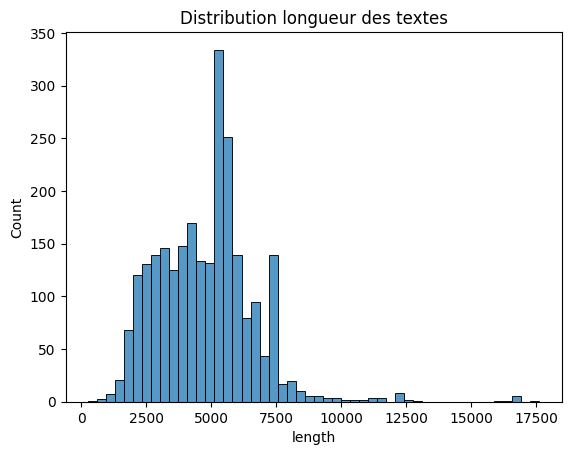

In [5]:
df['length'] = df['text'].apply(len)

sns.histplot(df['length'], bins=50)
plt.title("Distribution longueur des textes")
plt.show()

## WordCloud

In [7]:
%pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 550.7/550.7 kB 6.9 MB/s  0:00:00

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


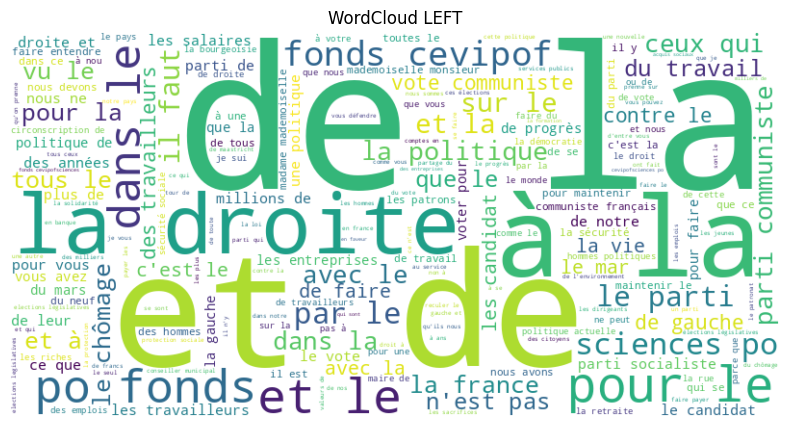

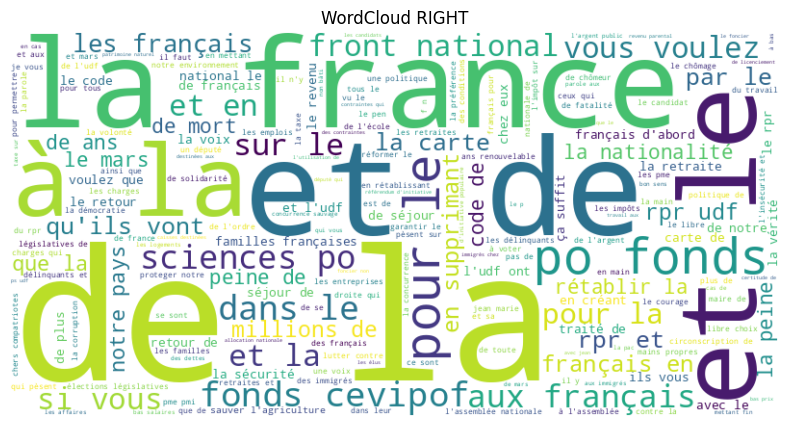

In [8]:
from wordcloud import WordCloud

def plot_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

text_left = " ".join(df[df.label=="left"].text)
text_right = " ".join(df[df.label=="right"].text)

plot_wordcloud(text_left, "WordCloud LEFT")
plot_wordcloud(text_right, "WordCloud RIGHT")

## Nettoyage 

In [9]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

df["text_clean"] = df["text"].apply(clean_text)

## Train / Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_clean"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# PARTIE 1 : BAG OF WORDS

## Vectorisation BOW

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

## Models BOW

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "NaiveBayes": MultinomialNB(),
    "SVM": LinearSVC()
}

for name, model in models.items():
    model.fit(X_train_bow, y_train)
    preds = model.predict(X_test_bow)
    
    print(f"\n=== {name} (BOW) ===")
    print(classification_report(y_test, preds))


=== LogReg (BOW) ===
              precision    recall  f1-score   support

        left       0.98      0.99      0.99       235
       right       0.99      0.99      0.99       270

    accuracy                           0.99       505
   macro avg       0.99      0.99      0.99       505
weighted avg       0.99      0.99      0.99       505


=== NaiveBayes (BOW) ===
              precision    recall  f1-score   support

        left       0.81      0.99      0.89       235
       right       0.99      0.80      0.89       270

    accuracy                           0.89       505
   macro avg       0.90      0.90      0.89       505
weighted avg       0.91      0.89      0.89       505


=== SVM (BOW) ===
              precision    recall  f1-score   support

        left       0.99      0.99      0.99       235
       right       0.99      0.99      0.99       270

    accuracy                           0.99       505
   macro avg       0.99      0.99      0.99       505
weighte

/home/onyxia/NLP-project/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


# PARTIE 2 : TF-IDF

## Vectorisation TF-IDF

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Modèles TF-IDF

In [14]:
results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    
    print(f"\n=== {name} (TF-IDF) ===")
    print(classification_report(y_test, preds))


=== LogReg (TF-IDF) ===
              precision    recall  f1-score   support

        left       0.99      0.97      0.98       235
       right       0.97      0.99      0.98       270

    accuracy                           0.98       505
   macro avg       0.98      0.98      0.98       505
weighted avg       0.98      0.98      0.98       505


=== NaiveBayes (TF-IDF) ===
              precision    recall  f1-score   support

        left       0.91      0.98      0.94       235
       right       0.98      0.91      0.95       270

    accuracy                           0.95       505
   macro avg       0.95      0.95      0.95       505
weighted avg       0.95      0.95      0.95       505


=== SVM (TF-IDF) ===
              precision    recall  f1-score   support

        left       0.99      0.99      0.99       235
       right       0.99      0.99      0.99       270

    accuracy                           0.99       505
   macro avg       0.99      0.99      0.99       50

Les résultats montrent que les modèles linéaires, notamment SVM et la régression logistique, atteignent des performances très élevées (F1-score ≈ 0.99). Cela s’explique par la forte structuration lexicale des discours politiques, où certains termes sont fortement associés à une orientation idéologique.

La vectorisation Bag-of-Words s’avère suffisante dans ce contexte, avec des performances comparables voire supérieures à TF-IDF.

En revanche, le modèle Naive Bayes présente des performances inférieures, notamment un déséquilibre dans la détection des classes, ce qui confirme ses limites liées à l’hypothèse d’indépendance des variables.

## Modèle final + Confusion Matrix

=== FINAL MODEL : SVM (TF-IDF) ===
              precision    recall  f1-score   support

        left       0.99      0.99      0.99       235
       right       0.99      0.99      0.99       270

    accuracy                           0.99       505
   macro avg       0.99      0.99      0.99       505
weighted avg       0.99      0.99      0.99       505



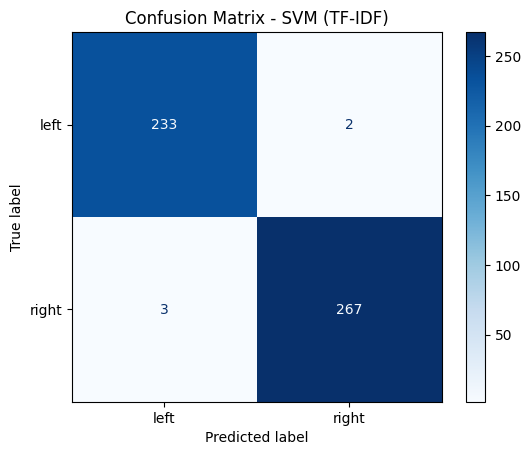

In [15]:
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

model = LinearSVC(max_iter=5000)
model.fit(X_train_tfidf, y_train)


y_pred = model.predict(X_test_tfidf)


print("=== FINAL MODEL : SVM (TF-IDF) ===")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred, labels=["left", "right"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["left", "right"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM (TF-IDF)")
plt.show()

Le modèle SVM avec vectorisation TF-IDF a été retenu comme modèle final en raison de ses performances élevées et équilibrées. La matrice de confusion montre une très faible proportion d’erreurs, confirmant la capacité du modèle à discriminer efficacement les orientations politiques.

Analysons un peu les mots qui ont plus contribué à la décision du modèle pour chaque classe. 

In [17]:
import pandas as pd

feature_names = tfidf.get_feature_names_out()

coefs = model.coef_[0]


df_coef = pd.DataFrame({
    "word": feature_names,
    "coef": coefs
})


df_coef_sorted = df_coef.sort_values(by="coef", ascending=False)


print("=== TOP MOTS DROITE ===")
print(df_coef_sorted.head(20))

print("\n=== TOP MOTS GAUCHE ===")
print(df_coef_sorted.tail(20))

=== TOP MOTS DROITE ===
              word      coef
4621         union  2.721158
2006        france  2.015608
3114    opposition  1.622252
4612           udf  1.386143
2269   immigration  1.164561
1871       famille  1.112106
3611     président  1.070124
2982      national  1.069624
3763  redressement  1.000961
1067     confiance  0.994964
3970           rpr  0.977035
3041         notre  0.928151
3047      nouvelle  0.829250
2907        morale  0.811183
859           chef  0.775694
851        charges  0.731438
3910     retrouver  0.728112
3762      redonner  0.710761
361     alternance  0.706444
1773          etat  0.700880

=== TOP MOTS GAUCHE ===
            word      coef
4251     sociale -0.725697
119           60 -0.729745
2544         les -0.761338
421      appelle -0.789132
752    candidats -0.790208
4565     travail -0.818206
3171        paix -0.819890
4254  socialiste -0.892062
3198     partage -0.935309
3702    radicaux -0.985588
4794        vote -0.996266
920     citoyens -

L’analyse des coefficients du modèle met en évidence des différences lexicales marquées entre les discours de gauche et de droite.

Les discours de droite sont associés à des termes liés à l’identité nationale, à l’autorité et à l’économie (ex : “immigration”, “président”, “redressement”), tandis que les discours de gauche mobilisent davantage un vocabulaire social et progressiste (ex : “solidarité”, “travail”, “progrès”).

Toutefois, certains mots fortement discriminants correspondent directement à des étiquettes politiques explicites (ex : “gauche”, “droite”, “parti”), ce qui introduit un biais dans la classification.

Pour cela nous allons supprimer ces mots biaisés là et refaire notre analyse. 

In [18]:
biased_words = [
    "gauche", "droite",
    "parti", "socialiste", "communiste",
    "rpr", "udf", "front", "national"
]

In [19]:
import re

def remove_biased_words(text):
    text = text.lower()
    for word in biased_words:
        text = re.sub(rf"\b{word}\b", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text_debiased"] = df["text"].apply(remove_biased_words)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_debiased"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


tfidf_clean = TfidfVectorizer(max_features=5000)

X_train_tfidf_clean = tfidf_clean.fit_transform(X_train)
X_test_tfidf_clean = tfidf_clean.transform(X_test)

model_clean = LinearSVC(max_iter=5000)
model_clean.fit(X_train_tfidf_clean, y_train)


y_pred_clean = model_clean.predict(X_test_tfidf_clean)

print("=== MODEL SANS BIAIS ===")
print(classification_report(y_test, y_pred_clean))

=== MODEL SANS BIAIS ===
              precision    recall  f1-score   support

        left       0.99      0.99      0.99       235
       right       0.99      0.99      0.99       270

    accuracy                           0.99       505
   macro avg       0.99      0.99      0.99       505
weighted avg       0.99      0.99      0.99       505



La suppression des termes explicitement liés aux orientations politiques (tels que “gauche”, “droite” ou les noms de partis) n’a entraîné aucune dégradation des performances du modèle.

Cela indique que la classification ne repose pas sur des indices lexicaux triviaux, mais sur des structures discursives plus profondes et des thématiques propres à chaque orientation politique.

Le modèle capture ainsi des patterns linguistiques complexes qui vont au-delà de simples mots-clés.

In [21]:
feature_names = tfidf_clean.get_feature_names_out()
coefs = model_clean.coef_[0]

In [22]:
df_coef = pd.DataFrame({
    "word": feature_names,
    "coef": coefs
})


df_coef_sorted = df_coef.sort_values(by="coef", ascending=False)


print("=== TOP MOTS DROITE ===")
print(df_coef_sorted.head(20))

print("\n=== TOP MOTS GAUCHE ===")
print(df_coef_sorted.tail(20))

=== TOP MOTS DROITE ===
              word      coef
4618         union  3.045991
2006        france  2.358973
3109    opposition  1.792163
2265   immigration  1.394815
1871       famille  1.220294
3607     président  1.163027
3759  redressement  1.147446
1065     confiance  1.109420
3036         notre  1.051383
3042      nouvelle  0.962499
2904        morale  0.856148
860           chef  0.837467
3905     retrouver  0.834267
1773          etat  0.824446
852        charges  0.812478
2702      majorité  0.797243
3758      redonner  0.784321
361     alternance  0.765261
3247          pays  0.751989
1947      fiscales  0.724388

=== TOP MOTS GAUCHE ===
             word      coef
822         cette -0.740061
2805       mesure -0.740273
118            60 -0.743381
2542          les -0.752826
4246      sociale -0.791617
421       appelle -0.805259
1009  communistes -0.807455
2189       heures -0.809732
4168      semaine -0.816616
4563      travail -0.867614
3165         paix -0.898466
752   

Après suppression des termes explicitement liés aux orientations politiques, l’analyse des coefficients montre que le modèle s’appuie sur des thématiques discursives cohérentes avec les idéologies politiques.
Les discours de droite sont associés à des notions d’autorité, d’économie et d’identité nationale, tandis que les discours de gauche mobilisent un vocabulaire lié à la solidarité, au travail et au progrès social.
Cette observation confirme que le modèle capture des structures linguistiques profondes et non de simples mots-clés